In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Dataset Prepartation**

In [51]:
# 데이터셋 준비
url = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

# 'engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg'
df=pd.read_csv(url, usecols=['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg'])

**EDA**

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

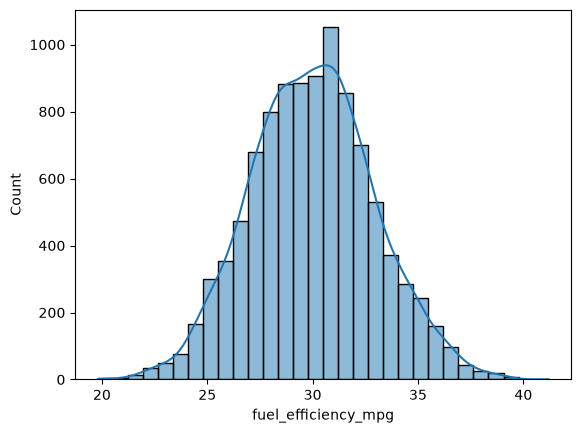

In [52]:
sns.histplot(df['fuel_efficiency_mpg'], bins=30, kde=True)

**Question1**
- There's one column with missing values. What is it?

In [53]:
df.isnull().sum()

model_year               0
engine_displacement      0
horsepower             877
vehicle_weight           0
fuel_efficiency_mpg      0
dtype: int64

**Question2**
- What's the median (50% percentile) for variable 'horsepower'?

In [54]:
# horsepower의 median 구하기
df['horsepower'].median()

np.float64(254.0)

**Split Data**

In [57]:
# lineary regression model 정의
df.info() # 수치형 column들만 존재

# 전처리 함수
def prepare_X(df):
    df = df.copy()
    # feature와 target 분리
    y = df['fuel_efficiency_mpg'].values
    X = df.drop(columns=['fuel_efficiency_mpg']).values
    return X, y

# 학습 함수 1
def train_linear_regression(X,y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
        
    # 4. 편향(w0)과 가중치(w)를 분리하여 반환
    return w_full[0], w_full[1:]

# 학습 함수 2
def train_linear_regression_with_r(X, y, r=0.001):
    # 1. 편향(bias)항을 위해 1로 채워진 절편 열(ones)을 생성
    ones = np.ones(X.shape[0])
    
    # 2. X의 맨 앞에 1로 이루어진 열을 추가 x0 / X*W = y
    X = np.column_stack([ones, X])

    # 3. 정규 방정식 (X^T * X)^(-1) * X^T * y 구하기
    ## 즉, 하나의 column이 다른 column들의 linear combination인 경우 역행렬이 존재하지 않음
    ## 의사역행렬을 직접 계산하거나 Identity Metrix에 0.001만큼의 작은 수를 더해서 존재하게 할 수 있음
    ## 최종 w가 커지지 않도록 조절함
    XTX = X.T.dot(X)
    # XTX_inv = np.linalg.pinv(XTX)
    XTX = XTX + r * np.eye(XTX.shape[0])
    
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    # 4. 편향(w0)과 가중치(w)를 분리하여 반환
    return w_full[0], w_full[1:]

# 평가 함수
def rmse(y,y_pred):
    error = y - y_pred
    mse = (error ** 2).mean()
    return np.sqrt(mse)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           10000 non-null  int64  
 1   engine_displacement  10000 non-null  int64  
 2   horsepower           9123 non-null   float64
 3   vehicle_weight       10000 non-null  int64  
 4   fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


**Question3**

In [ ]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42) # 42 기본
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
# 방법 1: horsepower 결측값을 0으로 채우기
df_train_v1 = df_train.copy()
df_val_v1 = df_val.copy()

df_train_v1["horsepower"] = df_train_v1["horsepower"].fillna(0)
df_val_v1["horsepower"] = df_val_v1["horsepower"].fillna(0)

train_X, train_y = prepare_X(df_train_v1)
val_X, val_y = prepare_X(df_val_v1)

w0_v1, w_v1 = train_linear_regression(train_X, train_y)
val_pred_v1 = w0_v1 + val_X.dot(w_v1)
score_v1 = round(rmse(val_y, val_pred_v1), 3)


# 방법 2: 학습 데이터의 horsepower 평균으로 채우기
df_train_v2 = df_train.copy()
df_val_v2 = df_val.copy()

horsepower_mean = df_train_v2["horsepower"].mean()
df_train_v2["horsepower"] = df_train_v2["horsepower"].fillna(horsepower_mean)
df_val_v2["horsepower"] = df_val_v2["horsepower"].fillna(horsepower_mean)

train_X, train_y = prepare_X(df_train_v2)
val_X, val_y = prepare_X(df_val_v2)

w0_v2, w_v2 = train_linear_regression(train_X, train_y)
val_pred_v2 = w0_v2 + val_X.dot(w_v2)
score_v2 = round(rmse(val_y, val_pred_v2), 3)

print("Fill with 0:", score_v1)
print("Fill with mean:", score_v2)

Fill with 0: 2.205
Fill with mean: 2.202


**Question4**

In [ ]:
train = df_train.copy()
val = df_val.copy()

# horsepower 결측값을 0으로 채우되, DataFrame 형태는 유지
train["horsepower"] = train["horsepower"].fillna(0)
val["horsepower"] = val["horsepower"].fillna(0)

X_train, y_train = prepare_X(train)
X_val, y_val = prepare_X(val)

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_with_r(X_train, y_train, r)
    y_pred = w0 + X_val.dot(w)
    score = round(rmse(y_val, y_pred), 4)
    print(f"r={r}: RMSE={score}")

r=0: RMSE=2.2053
r=0.01: RMSE=2.2058
r=0.1: RMSE=2.2241
r=1: RMSE=2.3492
r=5: RMSE=2.4094
r=10: RMSE=2.4195
r=100: RMSE=2.4292


**Question5**

In [ ]:
# scores = []

# for seed in range(10):
#     # seed별로 전체 데이터를 섞고 60% / 20% / 20%로 분할
#     df_shuffled = df.sample(frac=1, random_state=seed).reset_index(drop=True)

#     n = len(df_shuffled)
#     n_train = int(n * 0.6)
#     n_val = int(n * 0.2)

#     train = df_shuffled.iloc[:n_train].copy()
#     val = df_shuffled.iloc[n_train:n_train + n_val].copy()
#     test = df_shuffled.iloc[n_train + n_val:].copy()  # 분할 비율에 맞춘 테스트 데이터

#     # horsepower 결측값을 0으로 채우기
#     train["horsepower"] = train["horsepower"].fillna(0)
#     val["horsepower"] = val["horsepower"].fillna(0)

#     X_train, y_train = prepare_X(train)
#     X_val, y_val = prepare_X(val)

#     # 정규화 없이 학습
#     w0, w = train_linear_regression(X_train, y_train)

#     # 검증 데이터 RMSE
#     y_pred = w0 + X_val.dot(w)
#     scores.append(rmse(y_val, y_pred))

# print("RMSE scores:", scores)
# print("Standard deviation:", round(np.std(scores), 3))

RMSE scores: [np.float64(2.2392041430526595), np.float64(2.202112821084027), np.float64(2.163419778753098), np.float64(2.2043588768546103), np.float64(2.2018800943328625), np.float64(2.245785150908092), np.float64(2.269721207951279), np.float64(2.1907945999346996), np.float64(2.216611201700008), np.float64(2.207036592825467)]
Standard deviation: 0.029


**Question6**

In [58]:
# 위의 코드 다시 실행 > seed 9로 변경
# seed 9로 60% / 20% / 20% 분할
df_shuffled = df.sample(frac=1, random_state=9).reset_index(drop=True)

n = len(df_shuffled)
n_train = int(n * 0.6)
n_val = int(n * 0.2)

train = df_shuffled.iloc[:n_train].copy()
val = df_shuffled.iloc[n_train:n_train + n_val].copy()
test = df_shuffled.iloc[n_train + n_val:].copy()

# train과 validation을 합쳐 최종 학습 데이터로 사용
df_train_val = pd.concat([train, val], ignore_index=True)

# Q1의 결측값 열인 horsepower를 0으로 채우기
df_train_val["horsepower"] = df_train_val["horsepower"].fillna(0)
test["horsepower"] = test["horsepower"].fillna(0)

X_train_val, y_train_val = prepare_X(df_train_val)
X_test, y_test = prepare_X(test)

# r=0.001로 학습하고 test에서 평가
w0, w = train_linear_regression_with_r(X_train_val, y_train_val, 0.001)
y_pred = w0 + X_test.dot(w)

score = rmse(y_test, y_pred)
print(score)


2.2358277471948815
